Dataset Loaded!

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   model   32 non-null     object 
 1   mpg     32 non-null     float64
 2   cyl     32 non-null     int64  
 3   disp    32 non-null     float64
 4   hp      32 non-null     int64  
 5   drat    32 non-null     float64
 6   wt      32 non-null     float64
 7   qsec    32 non-null     float64
 8   vs      32 non-null     int64  
 9   am      32 non-null     int64  
 10  gear    32 non-null     int64  
 11  carb    32 non-null     int64  
dtypes: float64(5), int64(6), object(1)
memory usage: 3.1+ KB
None

Statistical Summary:
         mpg    cyl    disp      hp   drat     wt   qsec     vs     am   gear  \
count  32.00  32.00   32.00   32.00  32.00  32.00  32.00  32.00  32.00  32.00   
mean   20.09   6.19  230.72  146.69   3.60   3.22  17.85   0.44   0.41   3.69   
std     6.03   1

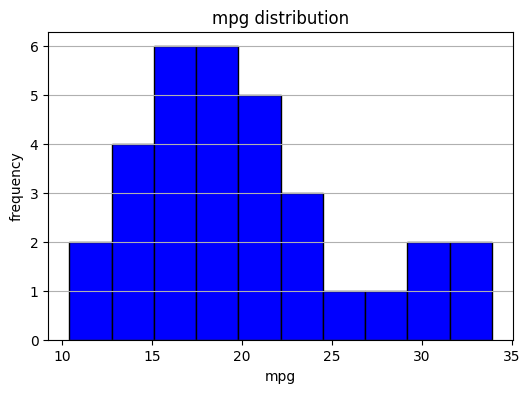

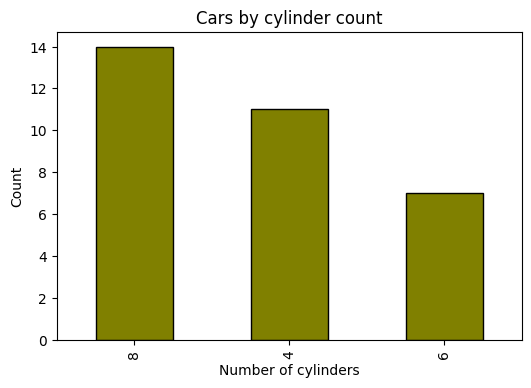

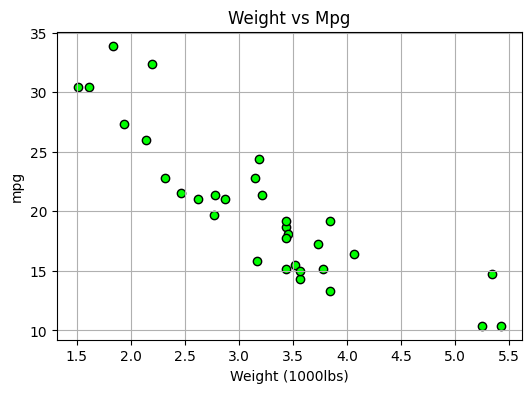

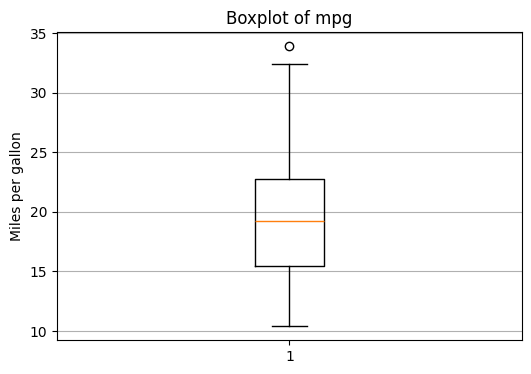

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("prac_datasets/mtcars.csv")
print("Dataset Loaded!\n")

print("Dataset info:")
print(df.info())
print(f"\nStatistical Summary:\n{df.describe().round(2)}")

print(f"\nAvergae Mileage: {df["mpg"].mean():.2f}")
highest_mpg = df.loc[df["mpg"].idxmax(),"model"]
print("Car with highest mpg: ",highest_mpg)

cyl_counts = df["cyl"].value_counts()
print(f"Num of cars by cyl: {cyl_counts}")

plt.figure(figsize=(6,4))
plt.hist(df["mpg"], bins=10, color="blue",edgecolor="black")
plt.xlabel("mpg")
plt.ylabel("frequency")
plt.title("mpg distribution")
plt.grid(axis='y')
plt.show()

plt.figure(figsize=(6,4))
cyl_counts.plot(kind="bar",color="olive",edgecolor = "black")
plt.xlabel("Number of cylinders")
plt.ylabel("Count")
plt.title("Cars by cylinder count")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(df["wt"],df["mpg"], color = "lime", edgecolor = "black")
plt.xlabel("Weight (1000lbs)")
plt.ylabel("mpg")
plt.title("Weight vs Mpg")
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.boxplot(df["mpg"])
plt.ylabel("Miles per gallon")
plt.title("Boxplot of mpg")
plt.grid(axis='y')
plt.show()


5-num summary before data preprocessing:
       protein    fat  sodium  fiber  carbohydrates  sugars  vitamins
count     10.0  10.00   10.00  10.00          10.00   10.00      10.0
mean       2.8   0.90  231.90   1.70          22.70   12.10      25.0
std        1.4   0.99  147.51   1.42           1.89   12.31       0.0
min        1.0  -1.00   -1.00  -1.00          20.00   -1.00      25.0
25%        2.0   0.25  200.00   1.00          21.25    7.25      25.0
50%        2.5   1.00  210.00   1.50          22.50    9.50      25.0
75%        3.0   1.75  237.50   2.75          23.75   12.00      25.0
max        6.0   2.00  600.00   4.00          26.00   45.00      25.0
5-num summary after filling missing values:
       protein    fat  sodium  fiber  carbohydrates  sugars  vitamins
count     10.0  10.00   10.00  10.00          10.00   10.00      10.0
mean       2.8   1.11  257.78   2.00          22.70   13.56      25.0
std        1.4   0.74  122.73   1.05           1.89   11.42       0.0
min  

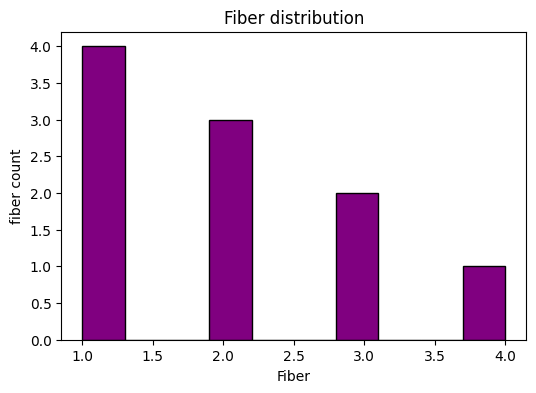

AttributeError: Line2D.set() got an unexpected keyword argument 'kind'

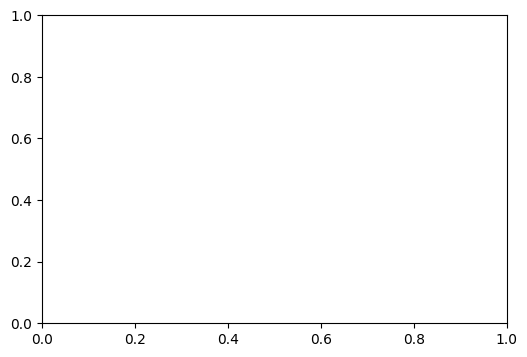

In [14]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("prac_datasets/cereals.csv")

numeric_cols = df.loc[:, "protein":"vitamins"].columns

print("5-num summary before data preprocessing:")
print(df[numeric_cols].describe().round(2))

for col in numeric_cols:
    valid_value = df[df[col] != -1][col]
    mean_value = valid_value.mean()
    df[col] = df[col].replace(-1, mean_value)

print("5-num summary after filling missing values:")
print(df[numeric_cols].describe().round(2))

for col in numeric_cols:
    median_val = df[col].median()
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr
    df[col] = np.where((df[col]<lower)|(df[col]>upper), median_val, df[col])

print("5-num summary after treating noisy values:")
print(df[numeric_cols].describe().round(2))

# Visualizations
plt.figure(figsize = (6,4))
plt.hist(df["fiber"], color = "purple", edgecolor="black")
plt.xlabel("Fiber")
plt.ylabel("fiber count")
plt.title("Fiber distribution")
plt.show()

plt.figure(figsize=(6,4))
plt.plot(df["protein"],kind="bar",color="lime")
plt.xlabel("protein")
plt.ylabel("protein count")
plt.show()